# Sanskrit Varna Sanyoga Analysis

This notebook analyzes वर्ण-संयोग (varna-sanyoga or character combinations) in Sanskrit texts, specifically focusing on anusvara (ं) followed by consonants. It organizes the Sanskrit consonants (व्यञ्जनानि) into their traditional वर्ग (varga) groups:

1. कवर्ग (Kavarga): क् ख् ग् घ् ङ्  
2. चवर्ग (Cavarga): च् छ् ज् झ् ञ्  
3. टवर्ग (Ṭavarga): ट् ठ् ड् ढ् ण्  
4. तवर्ग (Tavarga): त् थ् द् ध् न्  
5. पवर्ग (Pavarga): प् फ् ब् भ् म्  
6. यवर्ग (Yavarga): य्  
7. रवर्ग (Ravarga): र्  
8. लवर्ग (Lavarga): ल्  
9. ववर्ग (Vavarga): व्  
10. शवर्ग (Śavarga): श्  
11. षवर्ग (Ṣavarga): ष्  
12. सवर्ग (Savarga): स्  
13. हवर्ग (Havarga): ह्  

The notebook uses zoekt for searching and compares the distribution of these combinations across different texts.

In [58]:
# Import required libraries
import subprocess
import re
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

## Define Sanskrit Character Groups (Varna Varga)

Here we define the traditional Sanskrit character groups (vargas) and map each consonant to its respective varga. These groups are organized according to the place of articulation in the Sanskrit phonological system.

In [134]:
# Define the character groups
char_groups = {
    ('Kavarga', 'ka') : ['क्'], ('Kavarga', 'kha') : ['ख्'], ('Kavarga', 'ga') : ['ग्'], ('Kavarga', 'gha') : ['घ्'], ('Kavarga', 'nga') : ['ङ्'],
    ('Cavarga', 'cha') : ['च्'], ('Cavarga', 'chha') : ['छ्'], ('Cavarga', 'ja') : ['ज्'], ('Cavarga', 'jha') : ['झ्'], ('Cavarga', 'nya') : ['ञ्'],
    ('Ṭavarga', 'ṭa') : ['ट्'], ('Ṭavarga', 'ṭha') : ['ठ्'], ('Ṭavarga', 'ḍa') : ['ड्'], ('Ṭavarga', 'ḍha') : ['ढ्'], ('Ṭavarga', 'ṇa') : ['ण्'],
    ('Tavarga', 'ta') : ['त्'], ('Tavarga', 'tha') : ['थ्'], ('Tavarga', 'da') : ['द्'], ('Tavarga', 'dha') : ['ध्'], ('Tavarga', 'na') : ['न्'],
    ('Pavarga', 'pa') : ['प्'], ('Pavarga', 'pha') : ['फ्'], ('Pavarga', 'ba') : ['ब्'], ('Pavarga', 'bha') : ['भ्'], ('Pavarga', 'ma') : ['म्'],

    ('Yogavaṅśa', 'ya') : ['य्'], ('Yogavaṅśa', 'ra') : ['र्'], ('Yogavaṅśa', 'la') : ['ल्'], ('Yogavaṅśa', 'va') : ['व्'],
    ('Sibilant', 'śa') : ['श्'], ('Sibilant', 'ṣa') : ['ष्'], ('Sibilant', 'sa') : ['स्'],
    ('Visarga', 'ha'): ['ह्'], 
    # ('Anusvāra', 'aṃ'): ['ं'], ('Anusvāra', 'aḥ'): ['ः'], 
    # ('Vowel', 'a'): ['अ'],('Vowel', 'ā'): ['आ'],
    # ('Vowel', 'i'): ['इ'], ('Vowel', 'ī'): ['ई'], 
    # ('Vowel', 'u'): ['उ'], ('Vowel', 'ū'): ['ऊ'],
    # ('Vowel', 'e'): ['ए'], ('Vowel', 'ai'): ['ऐ'],
    # ('Vowel', 'o'): ['ओ'], ('Vowel', 'au'): ['औ']
}

# Define the varga groups
varga_groups = {
    'कवर्ग (Kavarga)': ['क्', 'ख्', 'ग्', 'घ्', 'ङ्'],
    'चवर्ग (Cavarga)': ['च्', 'छ्', 'ज्', 'झ्', 'ञ्'],
    'टवर्ग (Ṭavarga)': ['ट्', 'ठ्', 'ड्', 'ढ्', 'ण्'],
    'तवर्ग (Tavarga)': ['त्', 'थ्', 'द्', 'ध्', 'न्'],
    'पवर्ग (Pavarga)': ['प्', 'फ्', 'ब्', 'भ्', 'म्'],
    'य (Ya)': ['य्'],
    'र (Ra)': ['र्'],
    'ल (La)': ['ल्'],
    'व (Va)': ['व्'],
    'श (Śa)': ['श्'],
    'ष (Ṣa)': ['ष्'],
    'स (Sa)': ['स्'],
    'ह (Ha)': ['ह्'],
    # 'अनुस्वार (Anusvāra)': ['ं', 'ः'],
    # 'स्वर (Vowel)': ['अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ए', 'ऐ', 'ओ', 'औ']
}


In [135]:

# # Create a mapping from each character to its varga
# char_to_varga = {}
# for group_name, chars in varga_groups.items():
#     for char in chars:
#         char_to_varga[char] = group_name

# Create patterns for searching with zoekt
# Format: anusvara followed by a consonant with optional whitespace in between
vg_search_patterns = {}
for group_name, chars in varga_groups.items():
    # Join the characters with | for regex OR
    char_pattern = '|'.join(chars)
    # Create pattern for anusvara followed by any character from this varga
    vg_search_patterns[group_name] = f".ं\\s+[{char_pattern}]"

cg_search_patterns = {}
for group_name, chars in char_groups.items():
    # Join the characters with | for regex OR
    char_pattern = '|'.join(chars)
    # Create pattern for anusvara followed by any character from this group
    cg_search_patterns[group_name] = f".ं\\s+[{char_pattern}]"
    str_group_name = str(group_name)
    # Handle special cases for vowels and anusvāra
    if 'Vowel' in str_group_name :
        # For vowels and anusvāra, we don't need the anusvāra prefix
        pat = \
        "म" if "'a'" in str_group_name else \
        "मा" if "'ā'" in str_group_name else \
        "मि" if "'i'" in str_group_name else \
        "मी" if "'ī'" in str_group_name else \
        "मु" if "'u'" in str_group_name else \
        "मू" if "'ū'" in str_group_name else \
        "मे" if "'e'" in str_group_name else \
        "मै" if "'ai'" in str_group_name else \
        "मो" if "'o'" in str_group_name else \
        "मौ" if "'au'" in str_group_name else \
        "xमx"  # Default case, should not happen
        cg_search_patterns[group_name] = f"{pat}\S"

# Display the search patterns
print("Search patterns for each varga:")
for varga, pattern in vg_search_patterns.items():
    print(f"{varga}: {pattern}")

print("Search patterns for each consonant group:")
for group, pattern in cg_search_patterns.items():
    print(f"{group}: {pattern}")

Search patterns for each varga:
कवर्ग (Kavarga): .ं\s+[क्|ख्|ग्|घ्|ङ्]
चवर्ग (Cavarga): .ं\s+[च्|छ्|ज्|झ्|ञ्]
टवर्ग (Ṭavarga): .ं\s+[ट्|ठ्|ड्|ढ्|ण्]
तवर्ग (Tavarga): .ं\s+[त्|थ्|द्|ध्|न्]
पवर्ग (Pavarga): .ं\s+[प्|फ्|ब्|भ्|म्]
य (Ya): .ं\s+[य्]
र (Ra): .ं\s+[र्]
ल (La): .ं\s+[ल्]
व (Va): .ं\s+[व्]
श (Śa): .ं\s+[श्]
ष (Ṣa): .ं\s+[ष्]
स (Sa): .ं\s+[स्]
ह (Ha): .ं\s+[ह्]
Search patterns for each consonant group:
('Kavarga', 'ka'): .ं\s+[क्]
('Kavarga', 'kha'): .ं\s+[ख्]
('Kavarga', 'ga'): .ं\s+[ग्]
('Kavarga', 'gha'): .ं\s+[घ्]
('Kavarga', 'nga'): .ं\s+[ङ्]
('Cavarga', 'cha'): .ं\s+[च्]
('Cavarga', 'chha'): .ं\s+[छ्]
('Cavarga', 'ja'): .ं\s+[ज्]
('Cavarga', 'jha'): .ं\s+[झ्]
('Cavarga', 'nya'): .ं\s+[ञ्]
('Ṭavarga', 'ṭa'): .ं\s+[ट्]
('Ṭavarga', 'ṭha'): .ं\s+[ठ्]
('Ṭavarga', 'ḍa'): .ं\s+[ड्]
('Ṭavarga', 'ḍha'): .ं\s+[ढ्]
('Ṭavarga', 'ṇa'): .ं\s+[ण्]
('Tavarga', 'ta'): .ं\s+[त्]
('Tavarga', 'tha'): .ं\s+[थ्]
('Tavarga', 'da'): .ं\s+[द्]
('Tavarga', 'dha'): .ं\s+[ध्]
('Tavarga', 'na'): .ं\s+

## Implement Counting with Zoekt

Zoekt is a powerful code search tool. We'll use it to search for our pattern combinations across different Sanskrit texts. The following function executes zoekt commands and parses the results.

In [136]:
# decorate the function to cache results
def cache_results(func):
    """
    Decorator to cache results of the function
    """
    cache = {}

    def wrapper(*args, **kwargs):
        key = (args, frozenset(kwargs.items()))
        if key not in cache:
            cache[key] = func(*args, **kwargs)
        return cache[key]

    return wrapper

#invalidate the cache
def invalidate_cache():
    """
    Invalidate the cache for the search_zoekt function
    """
    search_zoekt.cache.clear()  

@cache_results
def search_zoekt(pattern, file_pattern):
    """
    Search for a pattern in files matching file_pattern using zoekt
    
    Args:
        pattern: The regex pattern to search for
        file_pattern: File pattern to limit search scope
        
    Returns:
        The count of occurrences
    """

    try:
        cmd = ["zoekt", pattern, f"file:{file_pattern}"]
        result = subprocess.run(cmd, capture_output=True, text=True)
        # Count lines in the output as a proxy for occurrences
        count = len(result.stdout.strip().split('\n')) if result.stdout.strip() else 0
        # print(f"{' '.join(cmd)} executed with return {count}")
        return count
    except Exception as e:
        print(f"Error searching for pattern '{pattern}': {e}")
        return 0

def perform_cross_tabulation(file_patterns, search_patterns, use_cache=True):
    """
    Perform cross-tabulation of pattern occurrences across files
    
    Args:
        file_patterns: List of file patterns to search
        
    Returns:
        DataFrame with cross-tabulation results
    """
    if not use_cache: invalidate_cache()

    print("Collecting data...")
    
    # Initialize a DataFrame to store results
    results = pd.DataFrame(index=search_patterns.keys(), columns=file_patterns + ['Total'])
    results = results.fillna(0)
    
    # Process each file pattern
    for file_pattern in file_patterns:
        print(f"Processing {file_pattern}...")
        # Process each group pattern
        for group_name, pattern in search_patterns.items():
            count = search_zoekt(pattern, file_pattern)
            results.at[group_name, file_pattern] = count
    
    # Calculate row totals
    results['Total'] = results.sum(axis=1)
    
    # Calculate column totals
    results.loc['Total'] = results.sum()
    
    return results

## Run the Analysis

Now let's run the analysis on our Sanskrit texts. We'll use the same file patterns as in the original shell script: raghuvamsham, kumarasambhava, and meghadutam.

In [178]:
# Define the file patterns to search
file_patterns = [
    'raghuvamsham', 'kumarasambhava', 'kiratarjuniya',
    'shishupala', 'naishadiya',
    'gita.*govinda' , 'madhuravijaya',
    'meghadutam.txt', 'ratnavali', 
    'valmiki-ramayana.txt' , '^.*MB.*BORI.*$',
    "ashtanga.*hrud",
    "aryabhatiya.txt",
    "tarkasangraha",
    "udayana",
    "bharata.*natya",
    "sahrudaya",
    "gaarg",
    "shakuntalam",
    "mrcc.*dev",
    "yougandharayanam.txt",
    "bhasa.*svapna",
    "mudra.*raks",
    # anargha by murari

]


# results_cg = perform_cross_tabulation(file_patterns, cg_search_patterns

ANUSVARA={}
for patterns, group_name in zip([vg_search_patterns, cg_search_patterns], ['Grouped Consonants', 'Individual Consonant']):
    print(f"\nCross-tabulation for {group_name} patterns:")
    # Perform cross-tabulation for varga patterns
    print("-" * 40)
    results = perform_cross_tabulation(file_patterns, patterns, use_cache=True)
    results.columns = [col.replace('.txt', '') for col in results.columns]
    # clean up columns names - remove special characters and edge spaces
    results.columns = [re.sub(r'[^a-zA-Z0-9_\S]', '', col).strip() for col in results.columns]
    results.columns = [re.sub(r'^\W*', '', col).strip() for col in results.columns]
    results.columns = [re.sub(r'\W*$', '', col).strip() for col in results.columns]
    results.columns = [re.sub(r'\W\W*', '_', col).strip() for col in results.columns]

    # normalize each cell by the sum of its column except for the 'Total' row
    results_normalized = results.copy().drop('Total', axis=0)
    for col in results_normalized.columns: 
        results_normalized[col] = results_normalized[col] / results_normalized[col].sum()


    ANUSVARA[group_name] = { 
        'raw': results,
        'normalized': results_normalized
    }

    # Display the results
    display(
        HTML(f"<h2>Anusvara+ Occurrences by {group_name}</h2>"),
        results_normalized.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption(f"Normalized Counts of Anusvara+ Occurrences by {group_name}"),
        HTML("<hr>"),
        HTML(f"<h2>Raw Counts of Anusvara+ Occurrences by {group_name}</h2>"),
        results.style.background_gradient(cmap='Reds').format("{:,}"),
        HTML("<hr>"))



Cross-tabulation for Grouped Consonants patterns:
----------------------------------------
Processing raghuvamsham...
Processing kumarasambhava...
Processing kiratarjuniya...
Processing shishupala...
Processing naishadiya...
Processing gita.*govinda...
Processing madhuravijaya...
Processing meghadutam.txt...
Processing ratnavali...
Processing valmiki-ramayana.txt...
Processing ^.*MB.*BORI.*$...
Processing ashtanga.*hrud...
Processing aryabhatiya.txt...
Processing tarkasangraha...
Processing udayana...
Processing bharata.*natya...
Processing sahrudaya...
Processing gaarg...
Processing shakuntalam...
Processing mrcc.*dev...
Processing yougandharayanam.txt...
Processing bhasa.*svapna...
Processing mudra.*raks...


,raghuvamsham,kumarasambhava,kiratarjuniya,shishupala,naishadiya,gita_govinda,madhuravijaya,meghadutam,ratnavali,valmiki_ramayana,MB_BORI,ashtanga_hrud,aryabhatiya,tarkasangraha,udayana,bharata_natya,sahrudaya,gaarg,shakuntalam,mrcc_dev,yougandharayanam,bhasa_svapna,mudra_raks,Total
कवर्ग (Kavarga),9.2%,11.4%,10.1%,12.4%,11.7%,17.1%,13.5%,10.6%,13.6%,9.6%,9.8%,11.6%,14.8%,9.9%,13.1%,10.8%,10.4%,10.6%,12.4%,14.9%,18.4%,16.0%,13.9%,10.3%
चवर्ग (Cavarga),6.9%,7.0%,6.3%,8.7%,5.6%,9.1%,6.0%,6.7%,10.1%,9.2%,10.6%,11.6%,8.9%,12.8%,11.3%,13.9%,9.9%,14.9%,5.6%,8.5%,3.9%,5.8%,9.1%,10.3%
टवर्ग (Ṭavarga),0.0%,0.0%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,4.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.2%,0.1%,0.0%,3.2%,2.7%,4.3%,1.7%,0.1%
तवर्ग (Tavarga),20.6%,21.7%,24.4%,19.0%,26.7%,18.7%,22.6%,24.6%,22.4%,21.1%,21.4%,18.0%,16.6%,21.5%,20.7%,23.3%,19.9%,19.0%,23.8%,21.1%,19.5%,18.0%,18.4%,21.1%
पवर्ग (Pavarga),24.5%,24.5%,24.4%,19.2%,21.3%,20.3%,22.2%,22.5%,25.7%,22.3%,23.8%,20.7%,20.1%,20.3%,15.3%,20.4%,19.5%,19.4%,26.3%,25.8%,26.7%,29.5%,21.2%,22.9%
य (Ya),3.7%,3.6%,2.6%,6.3%,4.4%,3.3%,2.5%,6.7%,1.3%,3.0%,4.3%,3.1%,5.3%,2.3%,3.2%,3.4%,5.8%,4.4%,2.7%,1.3%,2.4%,0.6%,3.8%,4.0%
र (Ra),4.4%,1.8%,2.4%,3.6%,2.2%,5.6%,3.7%,3.0%,1.7%,5.7%,2.9%,2.7%,1.8%,2.3%,1.8%,1.5%,4.0%,2.0%,3.8%,2.0%,2.0%,2.6%,3.6%,3.3%
ल (La),1.5%,0.8%,1.3%,1.5%,1.1%,1.2%,0.8%,1.4%,0.7%,1.4%,0.9%,1.6%,2.4%,1.2%,2.7%,1.3%,1.4%,0.8%,1.3%,0.6%,0.5%,0.5%,2.3%,1.1%
व (Va),10.3%,11.6%,13.9%,10.8%,10.7%,10.3%,10.2%,7.8%,7.7%,10.2%,9.4%,11.4%,7.1%,6.4%,14.0%,9.2%,12.1%,13.5%,9.2%,7.9%,8.6%,9.6%,9.4%,9.9%
श (Śa),4.4%,3.5%,3.3%,4.5%,3.4%,4.0%,4.1%,4.1%,1.1%,4.7%,4.2%,5.3%,5.3%,4.1%,3.2%,2.5%,5.0%,4.2%,3.3%,3.5%,3.9%,2.9%,4.2%,4.2%


,raghuvamsham,kumarasambhava,kiratarjuniya,shishupala,naishadiya,gita_govinda,madhuravijaya,meghadutam,ratnavali,valmiki_ramayana,MB_BORI,ashtanga_hrud,aryabhatiya,tarkasangraha,udayana,bharata_natya,sahrudaya,gaarg,shakuntalam,mrcc_dev,yougandharayanam,bhasa_svapna,mudra_raks,Total
कवर्ग (Kavarga),210,109,159,"1,056",513,73,65,46,95,"2,864","10,848","1,544",25,17,29,666,137,572,147,211,137,133,268,"19,924"
चवर्ग (Cavarga),159,67,99,741,243,39,29,29,71,"2,729","11,781","1,539",15,22,25,857,130,808,67,121,29,48,176,"19,824"
टवर्ग (Ṭavarga),1,0,0,6,1,0,0,0,28,0,1,0,0,0,0,2,3,3,0,45,20,36,32,178
तवर्ग (Tavarga),473,207,383,"1,609","1,166",80,109,107,157,"6,289","23,679","2,391",28,37,46,"1,435",262,"1,030",283,299,145,150,355,"40,720"
पवर्ग (Pavarga),562,234,383,"1,629",931,87,107,98,180,"6,642","26,412","2,741",34,35,34,"1,257",257,"1,048",312,365,199,246,409,"44,202"
य (Ya),85,34,41,536,193,14,12,29,9,885,"4,762",410,9,4,7,210,76,237,32,19,18,5,73,"7,700"
र (Ra),100,17,37,307,97,24,18,13,12,"1,690","3,217",357,3,4,4,94,53,108,45,28,15,22,69,"6,334"
ल (La),35,8,21,124,47,5,4,6,5,428,"1,045",212,4,2,6,78,18,44,15,8,4,4,45,"2,168"
व (Va),237,111,218,912,465,44,49,34,54,"3,021","10,394","1,513",12,11,31,568,160,733,109,112,64,80,182,"19,114"
श (Śa),101,33,51,382,150,17,20,18,8,"1,400","4,626",705,9,7,7,151,66,229,39,50,29,24,82,"8,204"



Cross-tabulation for Individual Consonant patterns:
----------------------------------------
Processing raghuvamsham...
Processing kumarasambhava...
Processing kiratarjuniya...
Processing shishupala...
Processing naishadiya...
Processing gita.*govinda...
Processing madhuravijaya...
Processing meghadutam.txt...
Processing ratnavali...
Processing valmiki-ramayana.txt...
Processing ^.*MB.*BORI.*$...
Processing ashtanga.*hrud...
Processing aryabhatiya.txt...
Processing tarkasangraha...
Processing udayana...
Processing bharata.*natya...
Processing sahrudaya...
Processing gaarg...
Processing shakuntalam...
Processing mrcc.*dev...
Processing yougandharayanam.txt...
Processing bhasa.*svapna...
Processing mudra.*raks...


,raghuvamsham,kumarasambhava,kiratarjuniya,shishupala,naishadiya,gita_govinda,madhuravijaya,meghadutam,ratnavali,valmiki_ramayana,MB_BORI,ashtanga_hrud,aryabhatiya,tarkasangraha,udayana,bharata_natya,sahrudaya,gaarg,shakuntalam,mrcc_dev,yougandharayanam,bhasa_svapna,mudra_raks,Total
"('Kavarga', 'ka')",6.2%,7.6%,5.8%,7.9%,8.3%,8.7%,10.0%,7.1%,8.2%,6.1%,6.7%,7.8%,6.9%,6.3%,10.2%,7.8%,7.4%,7.2%,7.9%,7.6%,9.7%,10.4%,8.9%,6.9%
"('Kavarga', 'kha')",0.1%,0.5%,0.2%,0.4%,0.6%,0.2%,0.2%,0.9%,1.3%,0.2%,0.1%,0.3%,1.1%,0.0%,0.0%,0.2%,0.1%,0.1%,1.0%,1.0%,1.4%,2.1%,0.8%,0.2%
"('Kavarga', 'ga')",2.6%,3.3%,3.7%,3.7%,2.1%,7.6%,3.2%,2.7%,4.1%,2.7%,2.5%,2.4%,5.7%,2.9%,1.8%,2.3%,2.0%,2.8%,3.1%,6.0%,6.3%,3.3%,3.7%,2.7%
"('Kavarga', 'gha')",0.0%,0.1%,0.4%,0.4%,0.5%,0.5%,0.4%,0.2%,0.0%,0.4%,0.3%,1.1%,1.1%,1.1%,0.7%,0.3%,0.5%,0.4%,0.1%,0.2%,0.6%,0.3%,0.4%,0.4%
"('Kavarga', 'nga')",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
"('Cavarga', 'cha')",4.2%,5.1%,2.3%,5.8%,3.2%,4.6%,3.4%,3.1%,3.6%,7.1%,8.2%,9.2%,6.9%,6.9%,7.7%,12.0%,7.4%,11.9%,3.3%,3.9%,2.9%,3.3%,5.2%,7.8%
"('Cavarga', 'chha')",0.3%,0.1%,0.2%,0.2%,0.1%,0.2%,0.0%,0.7%,0.0%,0.1%,0.2%,0.3%,1.1%,0.0%,0.0%,0.3%,0.4%,0.2%,0.2%,0.3%,0.3%,0.0%,0.4%,0.2%
"('Cavarga', 'ja')",2.4%,1.6%,3.7%,2.2%,2.1%,4.1%,2.6%,2.7%,5.8%,1.8%,2.1%,1.9%,1.1%,5.7%,2.9%,1.4%,1.3%,2.5%,2.0%,4.1%,0.6%,2.2%,3.1%,2.1%
"('Cavarga', 'jha')",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.3%,0.0%,0.0%,0.0%,0.0%,0.0%,0.4%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
"('Cavarga', 'nya')",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


,raghuvamsham,kumarasambhava,kiratarjuniya,shishupala,naishadiya,gita_govinda,madhuravijaya,meghadutam,ratnavali,valmiki_ramayana,MB_BORI,ashtanga_hrud,aryabhatiya,tarkasangraha,udayana,bharata_natya,sahrudaya,gaarg,shakuntalam,mrcc_dev,yougandharayanam,bhasa_svapna,mudra_raks,Total
"('Kavarga', 'ka')",146,75,94,766,377,38,50,32,62,"1,873","7,626","1,062",12,11,28,497,106,416,99,114,77,90,202,"13,853"
"('Kavarga', 'kha')",2,5,4,34,27,1,1,4,10,57,124,45,2,0,0,12,2,3,13,15,11,18,18,408
"('Kavarga', 'ga')",62,32,59,358,96,33,16,12,31,843,"2,869",332,10,5,5,148,29,162,39,90,50,29,84,"5,394"
"('Kavarga', 'gha')",1,1,6,34,21,2,2,1,0,124,386,152,2,2,2,17,7,22,1,3,5,3,8,802
"('Kavarga', 'nga')",0,0,0,0,0,0,0,0,0,31,0,0,0,0,0,0,0,0,0,0,0,0,0,31
"('Cavarga', 'cha')",98,50,37,561,146,20,17,14,27,"2,182","9,413","1,257",12,12,21,760,106,690,41,58,23,29,117,"15,691"
"('Cavarga', 'chha')",7,1,4,24,5,1,0,3,0,23,181,44,2,0,0,20,6,10,3,5,2,0,10,351
"('Cavarga', 'ja')",57,16,59,209,94,18,13,12,44,541,"2,390",259,2,10,8,86,19,147,25,62,5,19,70,"4,165"
"('Cavarga', 'jha')",0,0,0,1,2,0,0,0,2,1,4,0,0,0,1,1,1,0,0,0,0,0,0,13
"('Cavarga', 'nya')",0,0,0,0,0,0,0,0,0,18,0,0,0,0,0,0,0,0,0,0,0,0,0,18


## Visualize the Data

Let's create visualizations to better understand the distribution of these character combinations across different texts.

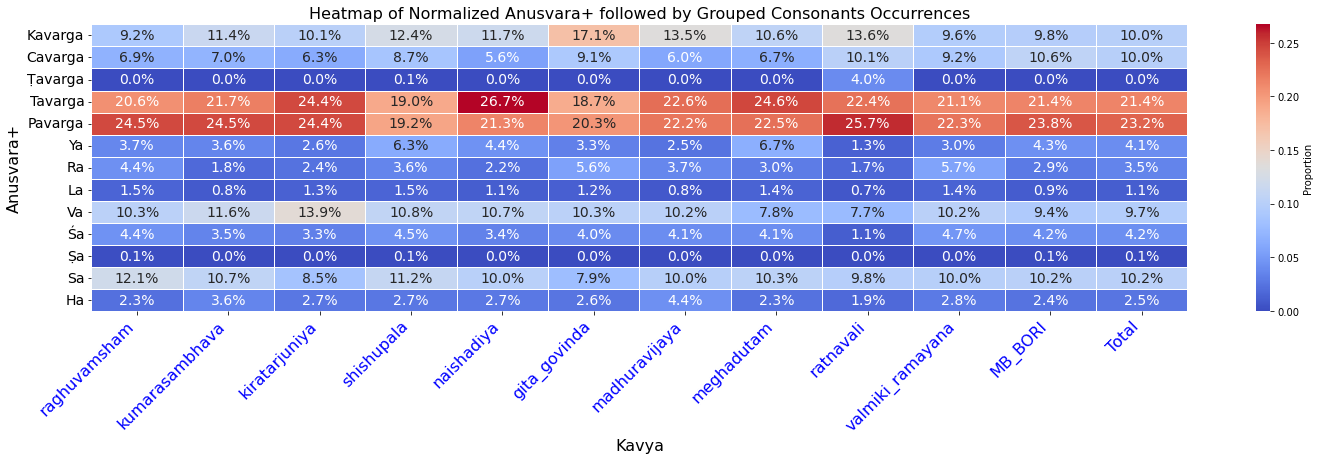

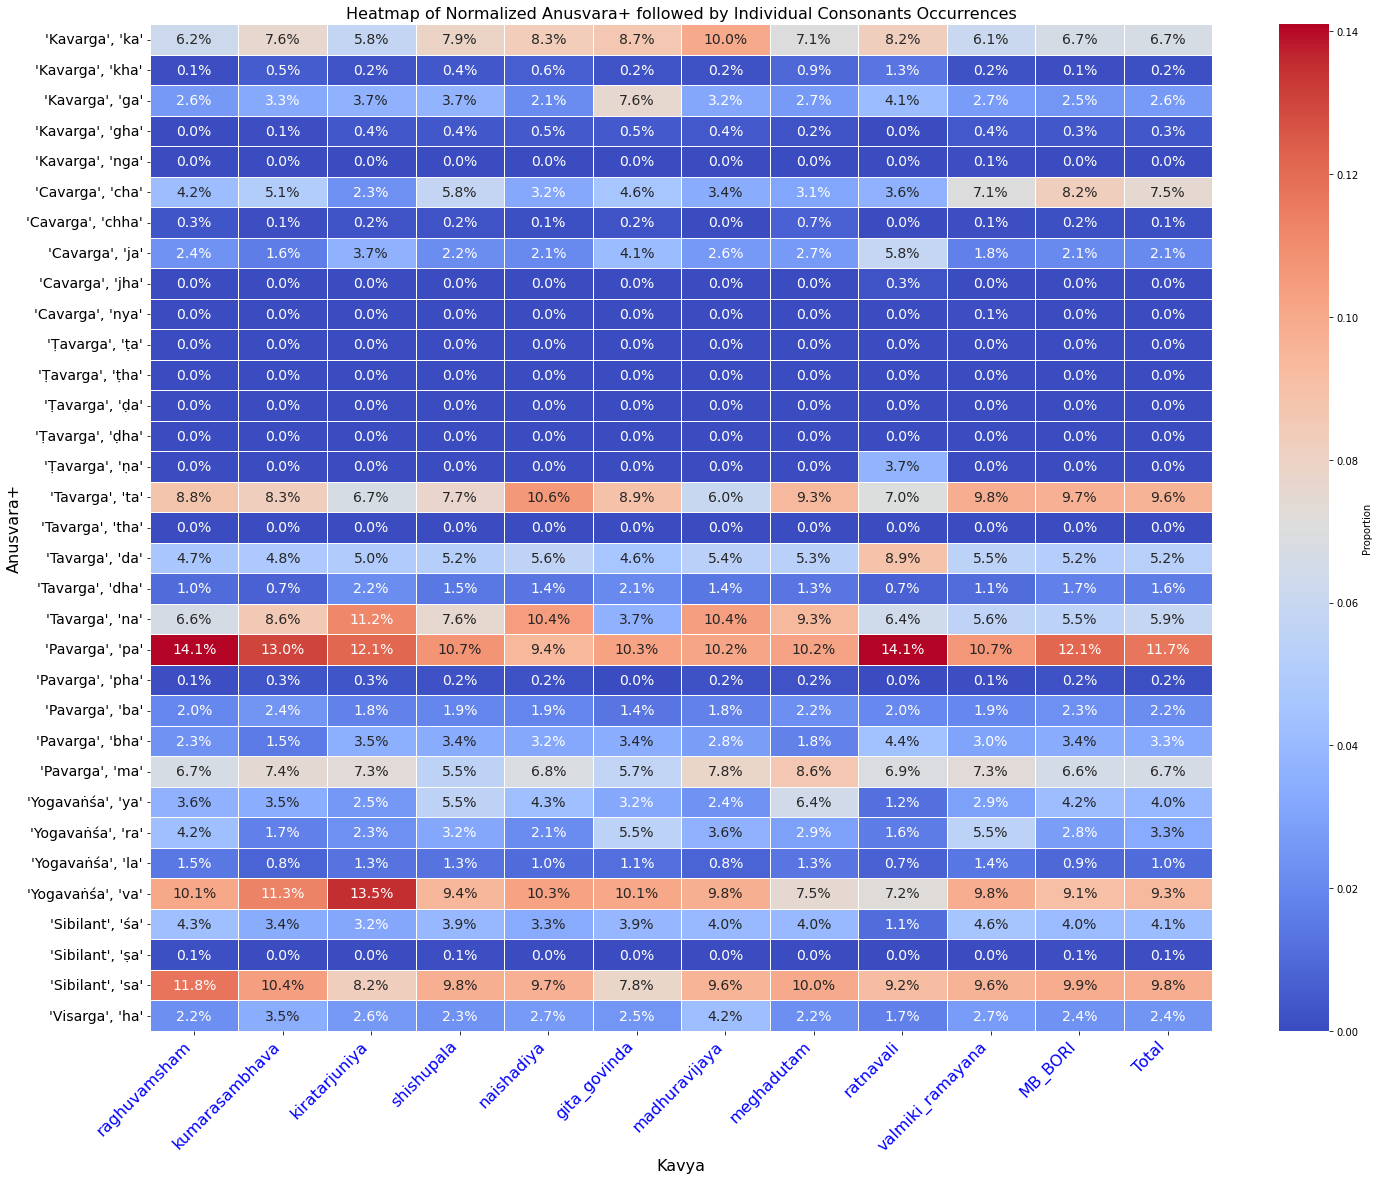

In [138]:
# function to create heatmap of normalized results using seaborn
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'Noto Sans Devanagari'
plt.rcParams['font.family'] = 'DejaVu Sans'

def plot_heatmap(data_in, title , fmt='.1%'):
    data = data_in.copy()
    # retain ( not remove) the content in parenthesis in the index
    data.index = [re.sub(r'^.*\((.*?)\).*$', r'\1', str(idx)).strip() for idx in data.index]

    plt.figure(figsize=(20, len(data) * 0.5))
    sns.heatmap(data, annot=True, fmt=fmt, cmap='coolwarm', cbar_kws={'label': 'Proportion'}, annot_kws={"size": 14}, linewidths=.5, linecolor='white')
    plt.title(title, fontsize=16)
    plt.xlabel('Kavya', fontsize=16)
    plt.xticks(fontsize=16, rotation=45 , color='blue')  # Rotate x-ticks for better readability
    plt.tight_layout()
    plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=45, ha='right')
    plt.ylabel('Anusvara+', fontsize=16)
    plt.yticks(fontsize=14, rotation=0)  # Rotate y-ticks for better readability
    plt.show()

# Plot the heatmap for normalized results
plot_heatmap(ANUSVARA['Grouped Consonants']['normalized'], "Heatmap of Normalized Anusvara+ followed by Grouped Consonants Occurrences")
plot_heatmap(ANUSVARA['Individual Consonant']['normalized'], "Heatmap of Normalized Anusvara+ followed by Individual Consonants Occurrences")




<Figure size 1008x576 with 0 Axes>

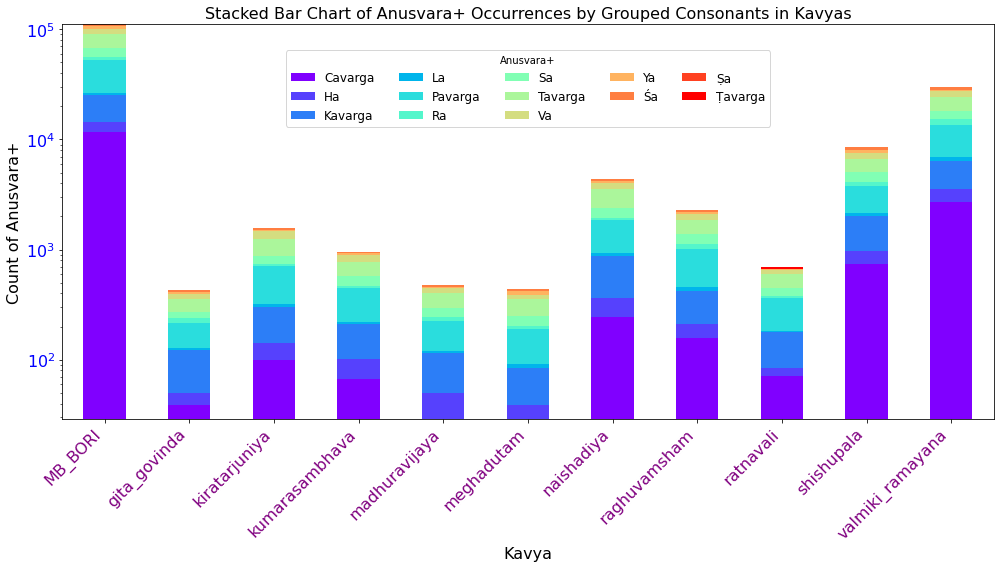

<Figure size 1008x576 with 0 Axes>

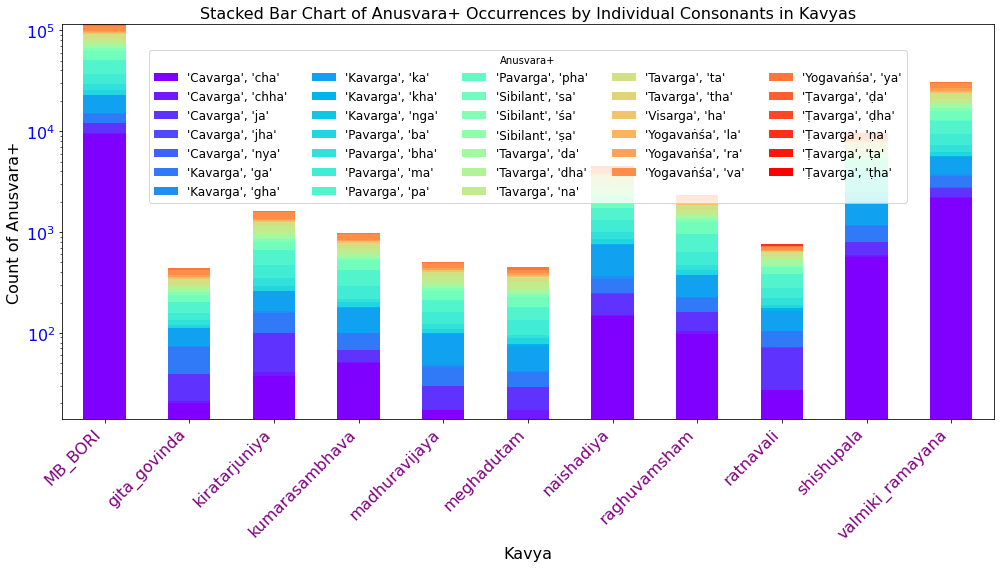

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

def plot_stacked_bar_chart(data, title):
    data = data.drop('Total', axis=0)
    data = data.drop('Total', axis=1)
    data.index = [re.sub(r'^.*\((.*?)\).*$', r'\1', str(idx)).strip() for idx in data.index]
    data.columns = [re.sub(r'^.*\((.*?)\).*$', r'\1', str(idx)).strip() for idx in data.columns]

    # Melt the DataFrame for seaborn
    melted_data = data.reset_index().melt(id_vars='index', var_name='Kavya', value_name='Count')
    melted_data.columns = ['Anusvara+', 'Kavya', 'Count']

    plt.figure(figsize=(14, 8))
    
    # Create a pivot table to group by 'Kavya'
    stacked_data = melted_data.pivot_table(index='Kavya', columns='Anusvara+', values='Count', aggfunc='sum')

    # Plot stacked bars
    stacked_data.plot(kind='bar', stacked=True, colormap='rainbow', figsize=(14, 8))

    plt.yscale('log')  # Log scale if needed
    plt.title(title, fontsize=16)
    plt.xlabel('Kavya', fontsize=16)
    plt.ylabel('Count of Anusvara+', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=16, color='purple')
    plt.yticks(fontsize=16, color='blue')
    
    plt.legend(title='Anusvara+', fontsize=12, loc='upper center', bbox_to_anchor=(0.5, .95), ncol=5)
    plt.tight_layout()
    plt.show()

# Example call
plot_stacked_bar_chart(ANUSVARA['Grouped Consonants']['raw'], "Stacked Bar Chart of Anusvara+ Occurrences by Grouped Consonants in Kavyas")
plot_stacked_bar_chart(ANUSVARA['Individual Consonant']['raw'], "Stacked Bar Chart of Anusvara+ Occurrences by Individual Consonants in Kavyas")


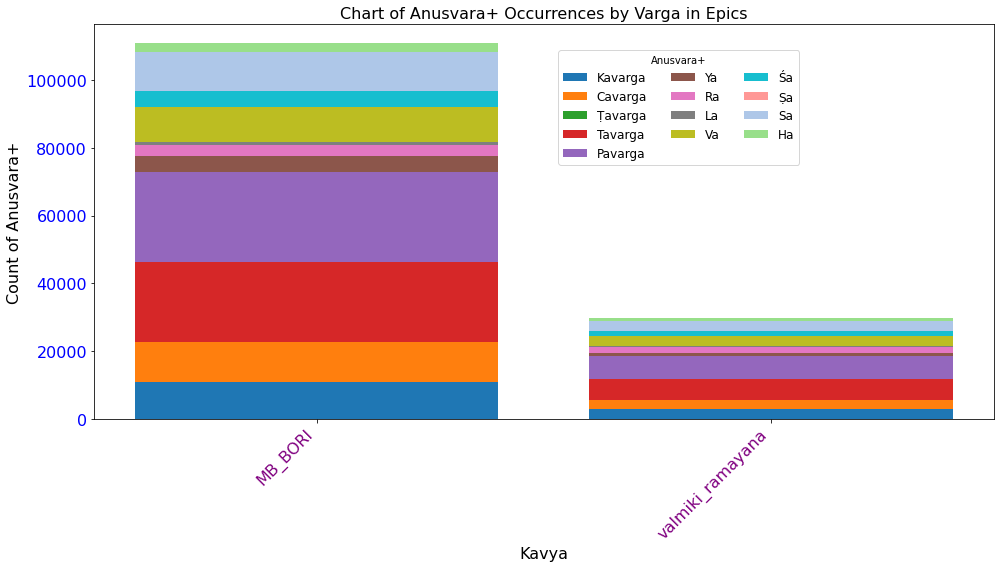

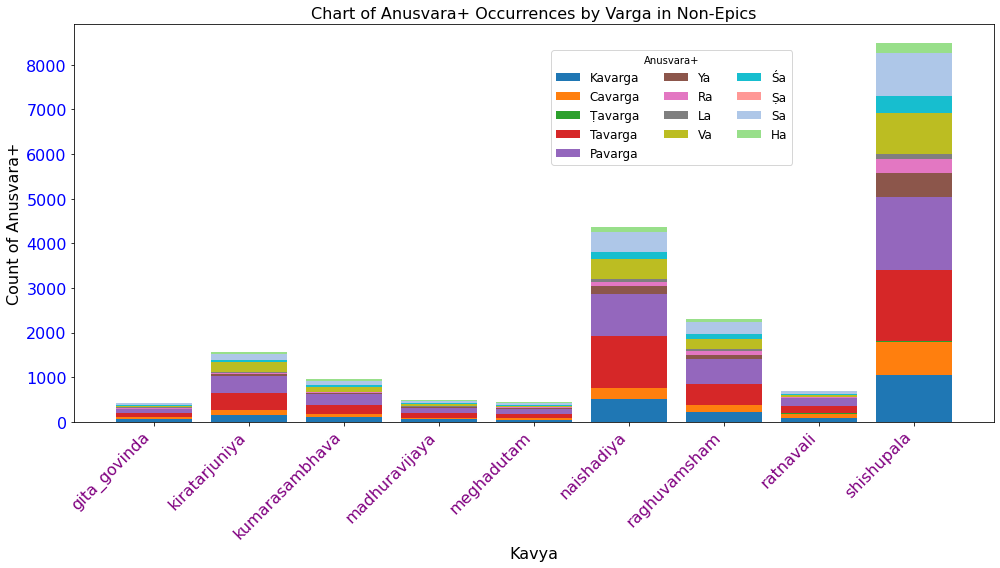

In [140]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# Define custom legend order and colors
custom_order = [
    "Kavarga", "Cavarga", "Ṭavarga", "Tavarga", "Pavarga",
    "Ya", "Ra", "La", "Va", "Śa", "Ṣa", "Sa", "Ha"
]

# Define custom colors
custom_palette = {
    "Kavarga": "#1f77b4", "Cavarga": "#ff7f0e", "Ṭavarga": "#2ca02c", "Tavarga": "#d62728",
    "Pavarga": "#9467bd", "Ya": "#8c564b", "Ra": "#e377c2", "La": "#7f7f7f",
    "Va": "#bcbd22", "Śa": "#17becf", "Ṣa": "#ff9896", "Sa": "#aec7e8", "Ha": "#98df8a"
}

def plot_stacked_bar_chart(data, title):
    # Clean up DataFrame
    if 'Total' in data.index: data = data.drop('Total', axis=0)
    if 'Total' in data.columns: data = data.drop('Total', axis=1)
    data.index = [re.sub(r'^.*\((.*?)\).*$', r'\1', idx).strip() for idx in data.index]
    data.columns = [re.sub(r'^.*\((.*?)\).*$', r'\1', idx).strip() for idx in data.columns]

    # Melt DataFrame into long format
    melted_data = data.reset_index().melt(id_vars='index', var_name='Kavya', value_name='Count')
    melted_data.columns = ['Anusvara+', 'Kavya', 'Count']

    # Pivot to prepare for stacking
    stacked_data = melted_data.pivot(index="Kavya", columns="Anusvara+", values="Count")

    # Plot stacked bars
    fig, ax = plt.subplots(figsize=(14, 8))
    bottom = np.zeros(len(stacked_data))

    for category in custom_order:
        if category in stacked_data.columns:
            ax.bar(stacked_data.index, stacked_data[category], label=category, color=custom_palette[category], bottom=bottom)
            bottom += stacked_data[category].fillna(0)  # Accumulate for stacking

    # Set log scale for y-axis
    # ax.set_yscale('log')

    plt.title(title, fontsize=16)
    plt.xlabel('Kavya', fontsize=16)
    plt.ylabel('Count of Anusvara+', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=16, color='purple')
    plt.yticks(fontsize=16, color='blue')

    # Adjust legend order & make it horizontal
    ax.legend(title='Anusvara+', fontsize=12, loc='upper center', bbox_to_anchor=(0.65, .95), ncol=3)

    plt.tight_layout()
    plt.show()

# Example call
epics = ['valmiki_ramayana', 'MB_BORI']
non_epics = [col for col in results.columns if col not in epics]
results = ANUSVARA['Grouped Consonants']['raw']
plot_stacked_bar_chart(results[epics], "Chart of Anusvara+ Occurrences by Varga in Epics")
plot_stacked_bar_chart(results[non_epics], "Chart of Anusvara+ Occurrences by Varga in Non-Epics")


In [141]:
results[epics]

,valmiki_ramayana,MB_BORI
कवर्ग (Kavarga),2864,10848
चवर्ग (Cavarga),2729,11781
टवर्ग (Ṭavarga),0,1
तवर्ग (Tavarga),6289,23679
पवर्ग (Pavarga),6642,26412
य (Ya),885,4762
र (Ra),1690,3217
ल (La),428,1045
व (Va),3021,10394
श (Śa),1400,4626


In [142]:
# ValueError: 'GnRd' is not a valid value for cmap; supported values are 
# 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 
# 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 
# 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 
# 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', '
# PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 
# 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 
# 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 
# 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 
# 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 
# 'crest', 'crest_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'flare', 'flare_r', 'gist_earth', 
# 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 
# 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 
# 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 
# 'icefire', 'icefire_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'mako', 'mako_r', 
# 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 
# 'rainbow', 'rainbow_r', 'rocket', 'rocket_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 
# 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 
# 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 
# 'viridis', 'viridis_r', 'vlag', 'vlag_r', 'winter', 'winter_r'

In [143]:
import re

def extract_content_under_heading(filename: str, heading: str) -> str:
    """Extracts content under the specified heading from a Markdown file."""
    with open(filename, "r", encoding="utf-8") as file:
        content = file.readlines()

    pattern = re.compile(rf"^#+\s*{heading}\s*$", re.IGNORECASE)
    extracting = False
    extracted_content = []

    for line in content:
        if pattern.match(line.strip()):
            extracting = True
            continue
        elif extracting and re.match(r"^#+\s", line.strip()):
            extracting = not True
        if extracting:
            extracted_content.append(line)

    return "".join(extracted_content).strip()

from glob import glob

in_mds = glob("*_output.md")
pcd_mds = [ f"zpadacheda_{re.sub(r'_padacheda_output.md$', '', md)}.md" for md in in_mds]
# Ensure the output directory exists

# Extract content under "Padacheda:" heading from each input Markdown file
for in_md, out_md in zip(in_mds, pcd_mds):
    print(f"Extracting content from {in_md} to {out_md}")
    content = extract_content_under_heading(in_md, "Padacheda:")
    with open(out_md, "w", encoding="utf-8") as file:
        file.write(content)

### Patterns म् + स्वर:
msvara_mds = [ f"zmsvara_{re.sub(r'_padacheda_output.md$', '', md)}.md" for md in in_mds]
for in_md, out_md in zip(in_mds, msvara_mds):
    # skip if the output file already exists
    if out_md in glob("*.md"):
        print(f"*** Skipping {out_md} as it already exists.")
        continue
    
    print(f"Extracting content from {in_md} to {out_md}")
    content = extract_content_under_heading(in_md, "Patterns म् . स्वर:")
    content_lines = content.splitlines()
    # first two lines are the header
    con = content_lines[:2]
    # rest is the content
    rest = content_lines[2:]
    # filter lines containing \d+\s*\|\s*$
    content = [line for line in rest if re.search(r"[1-9]\d*\s*\|\s*$", line)]
    # reduce mutiple spaces to single space
    content = [re.sub(r'\s+', ' ', line.strip()) for line in content]
    # filter lines with **
    content = [line for line in content if not re.search(r"\*\*", line)]
    # join the lines back
    content = "\n".join(content)

    with open(out_md, "w", encoding="utf-8") as file:
        file.write(content)


Extracting content from kalidasa_meghadutam_padacheda_output.md to zpadacheda_kalidasa_meghadutam.md
Extracting content from shriharsha_naishadiya_charitam_padacheda_output.md to zpadacheda_shriharsha_naishadiya_charitam.md
Extracting content from jayadeva_gita_govinda_padacheda_output.md to zpadacheda_jayadeva_gita_govinda.md
Extracting content from gangadevi_madhuravijaya_padacheda_output.md to zpadacheda_gangadevi_madhuravijaya.md
Extracting content from kalidasa_raghuvamsham_padacheda_output.md to zpadacheda_kalidasa_raghuvamsham.md
Extracting content from kalidasa_kumarasambhava_padacheda_output.md to zpadacheda_kalidasa_kumarasambhava.md
Extracting content from bharavi_kiratarjuniya_padacheda_output.md to zpadacheda_bharavi_kiratarjuniya.md
Extracting content from magha_shishupala_vadha_padacheda_output.md to zpadacheda_magha_shishupala_vadha.md
*** Skipping zmsvara_kalidasa_meghadutam.md as it already exists.
*** Skipping zmsvara_shriharsha_naishadiya_charitam.md as it already e

In [144]:
zmsvara_pat_mds = {}
zmsvara_mds = glob("zmsvara_*.md")
for f in zmsvara_mds:
    for p in file_patterns:
        zmsvara_pat_mds[p] = zmsvara_pat_mds.get(p, []) 
        if re.search(p, f):
            zmsvara_pat_mds[p] = zmsvara_pat_mds.get(p, []) + [f]
# Display the mapping of file patterns to zmsvara files
for p, files in zmsvara_pat_mds.items():
    print(f"{p}: {', '.join(files)}")

raghuvamsham: zmsvara_kalidasa_raghuvamsham.md
kumarasambhava: zmsvara_kalidasa_kumarasambhava.md
kiratarjuniya: zmsvara_bharavi_kiratarjuniya.md
shishupala: zmsvara_magha_shishupala_vadha.md
naishadiya: zmsvara_shriharsha_naishadiya_charitam.md
gita.*govinda: zmsvara_jayadeva_gita_govinda.md
madhuravijaya: zmsvara_gangadevi_madhuravijaya.md
meghadutam.txt: 
ratnavali: 
valmiki-ramayana.txt: 
^.*MB.*BORI.*$: 


In [ ]:

zdfs = []
# Read each zmsvara file, normalize the Kavya name, and create a DataFrame
for pat, zfns in zmsvara_pat_mds.items():
    if not zfns: 
        print(f"No files found for pattern {pat}")
        continue

    zfn = zfns[0]
    print(f"\nProcessing {zfn}")
    norm_fm = re.sub(r'^zmsvara_', '', zfn)
    kavya = re.sub(r'.md$', '', norm_fm)
    zdf = pd.read_csv(zfn, sep='|', header=None, names=['x0', 'verse', 'svara', 'instance', 'count', 'x1']).drop(columns=['x0','x1'])

    norm_pat = pat.replace('.txt', '').strip()
    norm_pat = re.sub(r'[^a-zA-Z0-9_\S]', '', norm_pat)  # Normalize pattern to a valid column name
    norm_pat = re.sub(r'^\W*', '', norm_pat).strip()  # Remove leading non-word characters
    norm_pat = re.sub(r'\W*$', '', norm_pat).strip()  # Remove trailing non-word characters
    norm_pat = re.sub(r'\W\W*', '_', norm_pat).strip()  # Replace multiple non-word characters with a single underscore
    # Insert the Kavya name as the first column

    zdf.insert(0, 'kavya', norm_pat)
    # zdf.insert(0, 'kavya', kavya)
    print(f"Read {len(zdf)} rows from {zfn}")
    zdf['kavya'] = zdf['kavya'].str.strip()

    # zdf['count'] = zdf['count'].astype(int)
    # zdf['verse'] = zdf['verse'].str.strip()
    # zdf['svara'] = zdf['svara'].str.strip()
    # zdf['instance'] = zdf['instance'].str.strip()

    # prepend a column with the Kavya name
 
    zdfs.append(zdf)
# Concatenate all DataFrames into a single DataFrame
zdf = pd.concat(zdfs, ignore_index=True)

zdf.sample(11).style





Processing zmsvara_kalidasa_raghuvamsham.md
Read 1359 rows from zmsvara_kalidasa_raghuvamsham.md

Processing zmsvara_kalidasa_kumarasambhava.md
Read 576 rows from zmsvara_kalidasa_kumarasambhava.md

Processing zmsvara_bharavi_kiratarjuniya.md
Read 1044 rows from zmsvara_bharavi_kiratarjuniya.md

Processing zmsvara_magha_shishupala_vadha.md
Read 1863 rows from zmsvara_magha_shishupala_vadha.md

Processing zmsvara_shriharsha_naishadiya_charitam.md
Read 2672 rows from zmsvara_shriharsha_naishadiya_charitam.md

Processing zmsvara_jayadeva_gita_govinda.md
Read 269 rows from zmsvara_jayadeva_gita_govinda.md

Processing zmsvara_gangadevi_madhuravijaya.md
Read 58 rows from zmsvara_gangadevi_madhuravijaya.md
No files found for pattern meghadutam.txt
No files found for pattern ratnavali
No files found for pattern valmiki-ramayana.txt
No files found for pattern ^.*MB.*BORI.*$


,kavya,verse,svara,instance,count
1866,kumarasambhava,8.360000,इ,व्यक्तपङ्कम् इव,1
5595,naishadiya,6.73,अ,स्फुटम् अपि,1
711,raghuvamsham,10.21,ए,त्वम् एकः,1
6058,naishadiya,१०.९९,अ,अवरम् अंशुकेषु,1
6847,naishadiya,17.194,अ,आलम्बम् अम्बरे,1
283,raghuvamsham,5.21,अ,अर्थकार्श्यम् अचिन्तयित्वा,1
2045,kiratarjuniya,2.540000,अ,तम् अभीयाय,1
3704,shishupala,37,अ,"उपगूढवेलम् अलघु , अधिशम् अपि , गणम् अनङ्गलघुम्",3
3450,shishupala,60,उ,सुतराम् उपकारिणि,1
3058,shishupala,67,आ,पयोधिम् आबद्ध,1


In [164]:
zdf.svara = zdf.svara.str.strip()
zdf.kavya = zdf.kavya.str.strip()
zdf.verse = zdf.verse.str.strip()
zdf['count'] = zdf['count'].astype(int)
msvara_df = zdf.pivot_table(
    index='kavya', columns='svara', values='count', aggfunc='sum'
).fillna(0).astype(int).drop(columns=['Total' , 'अं']).T

# gist.columns = [ re.sub("_", "<br>", x) for x in gist.columns]
# gist.columns = [ "<br>".join(x.split("_")[1:]) for x in gist.columns]



In [165]:

msvara_normalized_df = msvara_df.copy()
for col in msvara_normalized_df.columns: 
    msvara_normalized_df[col] = msvara_normalized_df[col] / msvara_normalized_df[col].sum()


In [166]:
# Display the results
display(
    # HTML(f"<h2>Normalized म्+स्वरः Occurrences </h2>"),
    msvara_normalized_df.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption("<h3>Normalized Counts of म्+स्वरः Occurrences</h3>"),
    HTML("<hr>"),
    # HTML(f"<h2>Raw Counts of म्+स्वरः Occurrences</h2>"),
    msvara_df.style.background_gradient(cmap='Reds').format("{:,}").set_caption("<h3>Raw Counts of म्+स्वरः Occurrences</h3>")
)

kavya,gita_govinda,kiratarjuniya,kumarasambhava,madhuravijaya,naishadiya,raghuvamsham,shishupala
svara,,,,,,,
अ,57.1%,43.3%,44.3%,30.8%,53.1%,46.5%,52.5%
आ,4.6%,14.0%,20.0%,16.9%,13.8%,20.0%,11.8%
इ,21.8%,18.8%,13.3%,16.9%,11.2%,12.5%,12.4%
ई,0.3%,1.8%,1.5%,0.0%,1.8%,1.6%,1.4%
उ,12.0%,15.1%,11.3%,10.8%,9.6%,10.0%,13.9%
ऊ,0.6%,0.7%,0.5%,0.0%,0.9%,0.5%,0.8%
ऋ,0.0%,0.7%,1.1%,0.0%,0.3%,2.0%,0.3%
ए,3.7%,4.4%,7.2%,6.2%,8.3%,6.4%,6.1%
ऐ,0.0%,0.2%,0.6%,3.1%,0.7%,0.5%,0.3%


kavya,gita_govinda,kiratarjuniya,kumarasambhava,madhuravijaya,naishadiya,raghuvamsham,shishupala
svara,,,,,,,
अ,186,520,290,20,"1,658",709,"1,228"
आ,15,168,131,11,431,305,275
इ,71,226,87,11,350,190,289
ई,1,21,10,0,55,24,32
उ,39,181,74,7,298,152,325
ऊ,2,8,3,0,27,7,18
ऋ,0,8,7,0,8,31,7
ए,12,53,47,4,259,97,142
ऐ,0,3,4,2,21,7,7


In [ ]:
msvara_cols = msvara_df.columns.tolist()
anusvara_ind_df = ANUSVARA['Individual Consonant']['raw'][msvara_cols]
anusvara_grp_df = ANUSVARA['Grouped Consonants']['raw'][msvara_cols]

# stack msvara_df and anusvara_ind_df
_a = anusvara_ind_df.drop(index=['Total']).stack().reset_index()
_a.columns = ['svara', 'kavya', 'count']
_p = _a
# _p = _a[_a.svara.apply(lambda x: 'Pa' in str(x))]
# _pmap ={
#     ('Pavarga', 'pa'): 'प्',
#     ('Pavarga', 'pha'): 'फ्',
#     ('Pavarga', 'ba'): 'ब्',
#     ('Pavarga', 'bha'): 'भ्',
#     ('Pavarga', 'ma'): 'म्'
# }
# # Replace the 'svara' column values with the mapped values
# for k, v in _pmap.items():
#     _p.loc[_p.svara == k, 'svara'] = v


_m = msvara_df.stack().reset_index()
_m.columns = ['svara', 'kavya', 'count']
_m1 = _m[_m.svara.apply(lambda x: 'म्+' not in str(x))]
_m1 = _m1[_m1.svara.apply(lambda x: 'व' not in str(x))]
# display( _m.head().style , _a.head().style)

# Append _p to _m row wise
mboth_df = pd.concat([_m1, _p], ignore_index=True)

# mboth_df.columns = ['svara', 'kavya', 'count']
mboth_df = mboth_df.pivot_table(index='svara', columns='kavya', values='count', fill_value=0)

# delete mboth_df rows with svara containing म् +





mboth_normalized_df = mboth_df.copy()
# mboth_normalized_df = mboth_normalized_df.div(mboth_normalized_df.sum(axis=1), axis=0)
for col in mboth_normalized_df.columns: 
    mboth_normalized_df[col] = mboth_normalized_df[col] / mboth_normalized_df[col].sum()
# Display the results
display(
    # HTML(f"<h2>Normalized म्+स्वरः Occurrences by Individual Consonants</h2>"),
    mboth_normalized_df.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption("<h3>Normalized Counts of म्+स्वरः Occurrences by Individual Consonants</h3>"),
    HTML("<hr>"),
    # HTML(f"<h2>Raw Counts of म्+स्वरः Occurrences by Individual Consonants</h2>"),
    mboth_df.style.background_gradient(cmap='Reds').format("{:,}").set_caption("<h3>Raw Counts of म्+स्वरः Occurrences by Individual Consonants</h3>")
)

# display(
#     # HTML(f"<h2>Normalized म्+स्वरः Occurrences </h2>"),
#     msvara_normalized_df.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption("<h3>Normalized Counts of म्+स्वरः Occurrences</h3>"),
#     anusvara_ind_normalized_df.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption("<h3>Normalized Counts of म्+स्वरः Occurrences by Individual Consonants</h3>"),
#     anusvara_grp_normalized_df.style.format("{:.1%}").background_gradient(cmap='coolwarm').set_caption("<h3>Normalized Counts of म्+स्वरः Occurrences by Grouped Consonants</h3>"),
#     HTML("<hr>"),
#     # HTML(f"<h2>Raw Counts of म्+स्वरः Occurrences</h2>"),
#     msvara_df.style.background_gradient(cmap='Reds').format("{:,}").set_caption("<h3>Raw Counts of म्+स्वरः Occurrences</h3>"),
#     anusvara_ind_df.style.background_gradient(cmap='Reds').format("{:,}").set_caption("<h3>Raw Counts of म्+स्वरः Occurrences by Individual Consonants</h3>"),
#     anusvara_grp_df.style.background_gradient(cmap='Reds').format("{:,}").set_caption("<h3>Raw Counts of म्+स्वरः Occurrences by Grouped Consonants</h3>")

# )

kavya,gita_govinda,kiratarjuniya,kumarasambhava,madhuravijaya,naishadiya,raghuvamsham,shishupala
svara,,,,,,,
"('Cavarga', 'cha')",2.6%,1.3%,3.1%,3.1%,1.9%,2.5%,4.7%
"('Cavarga', 'chha')",0.1%,0.1%,0.1%,0.0%,0.1%,0.2%,0.2%
"('Cavarga', 'ja')",2.4%,2.1%,1.0%,2.3%,1.2%,1.5%,1.7%
"('Cavarga', 'jha')",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
"('Cavarga', 'nya')",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
"('Kavarga', 'ga')",4.3%,2.1%,2.0%,2.9%,1.3%,1.6%,3.0%
"('Kavarga', 'gha')",0.3%,0.2%,0.1%,0.4%,0.3%,0.0%,0.3%
"('Kavarga', 'ka')",5.0%,3.3%,4.6%,9.0%,4.9%,3.8%,6.4%
"('Kavarga', 'kha')",0.1%,0.1%,0.3%,0.2%,0.4%,0.1%,0.3%


kavya,gita_govinda,kiratarjuniya,kumarasambhava,madhuravijaya,naishadiya,raghuvamsham,shishupala
svara,,,,,,,
"('Cavarga', 'cha')",20.0,37.0,50.0,17.0,146.0,98.0,561.0
"('Cavarga', 'chha')",1.0,4.0,1.0,0.0,5.0,7.0,24.0
"('Cavarga', 'ja')",18.0,59.0,16.0,13.0,94.0,57.0,209.0
"('Cavarga', 'jha')",0.0,0.0,0.0,0.0,2.0,0.0,1.0
"('Cavarga', 'nya')",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"('Kavarga', 'ga')",33.0,59.0,32.0,16.0,96.0,62.0,358.0
"('Kavarga', 'gha')",2.0,6.0,1.0,2.0,21.0,1.0,34.0
"('Kavarga', 'ka')",38.0,94.0,75.0,50.0,377.0,146.0,766.0
"('Kavarga', 'kha')",1.0,4.0,5.0,1.0,27.0,2.0,34.0
